In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [7]:
df=pd.read_csv("StudentsPerformance.csv")

In [8]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [9]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [10]:
df.shape

(1000, 8)

In [12]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [18]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [19]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [20]:
df.duplicated().sum()

np.int64(0)

In [22]:
print(df['gender'].value_counts())

gender
female    518
male      482
Name: count, dtype: int64


In [23]:
print(df['lunch'].value_counts())

lunch
standard        645
free/reduced    355
Name: count, dtype: int64


In [25]:
print(df['race/ethnicity'].value_counts())

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


In [26]:
print(df['parental level of education'].value_counts())

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


In [28]:
print(df['test preparation course'].value_counts())

test preparation course
none         642
completed    358
Name: count, dtype: int64


In [57]:
df["PerformanceScore"]=(df["math score"]+df["writing score"]+df["reading score"])/3

In [59]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,score,Student,PerformanceScore
0,female,group B,bachelor's degree,standard,none,72,72,74,218,Stable,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,Stable,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,Stable,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,Unstable,49.333333
4,male,group C,some college,standard,none,76,78,75,229,Unstable,76.333333
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,Stable,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,Unstable,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,Unstable,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,Stable,74.333333


<Axes: xlabel='PerformanceScore', ylabel='Count'>

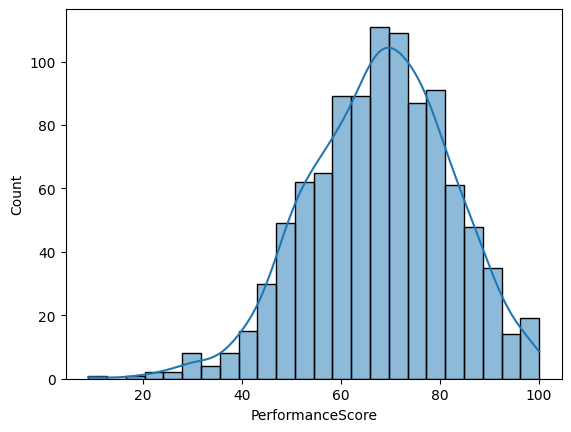

In [60]:
sns.histplot(df["PerformanceScore"],kde=True)

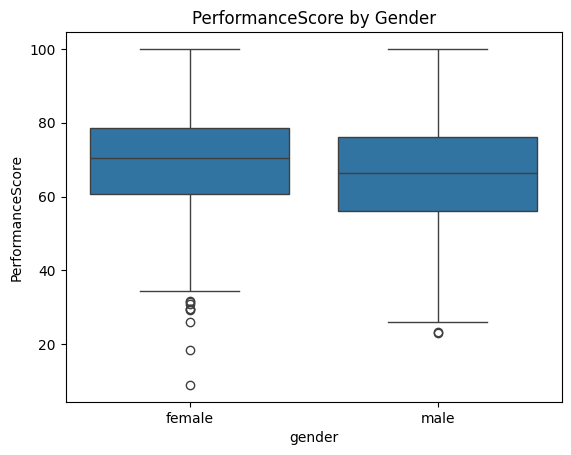

In [61]:


sns.boxplot(
    x="gender",
    y="PerformanceScore",
    data=df
)

plt.title("PerformanceScore by Gender")

plt.show()

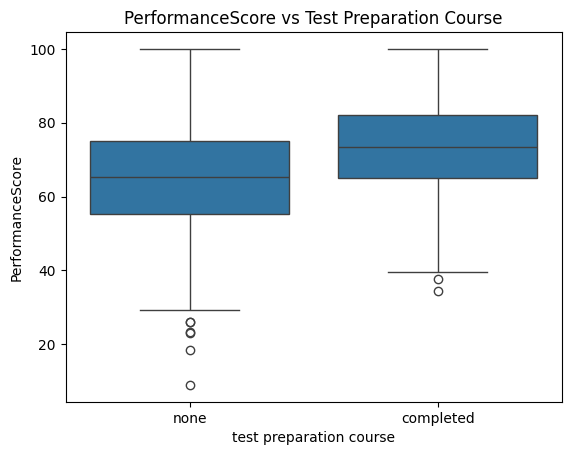

In [62]:

sns.boxplot(
    x="test preparation course",
    y="PerformanceScore",
    data=df
)

plt.title("PerformanceScore vs Test Preparation Course")

plt.show()

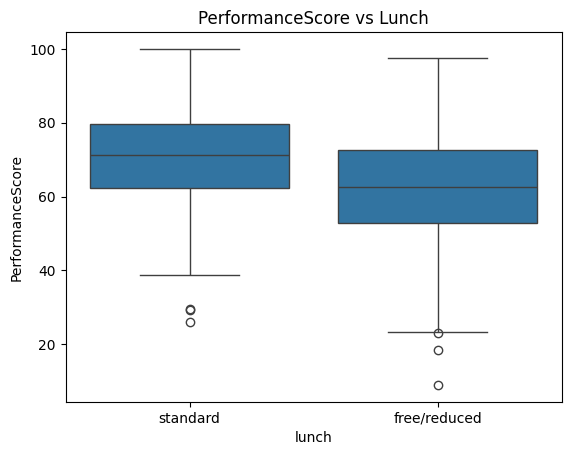

In [63]:

sns.boxplot(
    x="lunch",
    y="PerformanceScore",
    data=df
)

plt.title("PerformanceScore vs Lunch")

plt.show()

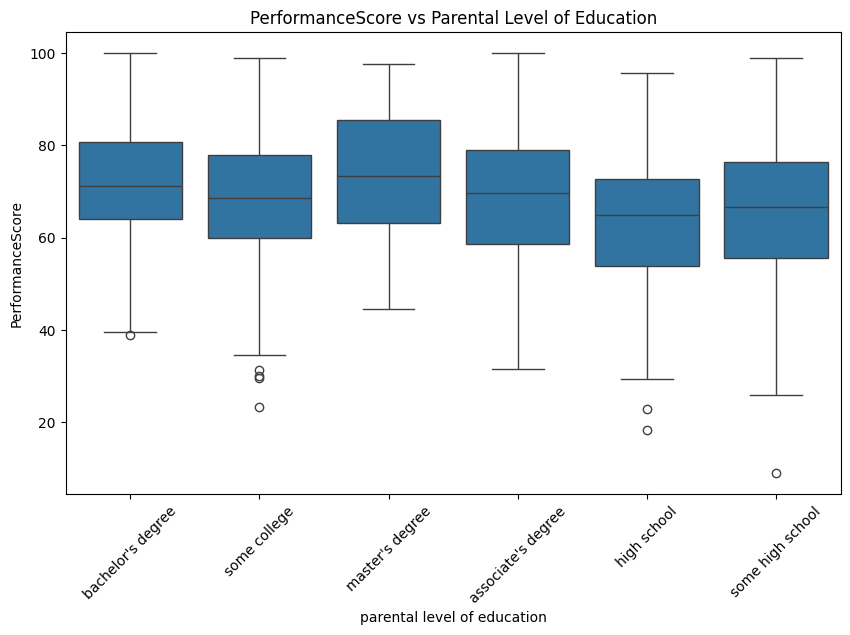

In [64]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x="parental level of education",
    y="PerformanceScore",
    data=df
)

plt.xticks(rotation=45)

plt.title("PerformanceScore vs Parental Level of Education")

plt.show()

In [66]:
X = df[
    [
        "gender",
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "test preparation course"
    ]
]

y = df["PerformanceScore"]

In [68]:
print(X.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  
0                    none  
1               completed  
2                    none  
3                    none  
4                    none  


In [71]:
print(y.head())

0    72.666667
1    82.333333
2    92.666667
3    49.333333
4    76.333333
Name: PerformanceScore, dtype: float64


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [72]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns

In [73]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)

#Linear Regression

In [74]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [75]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [96]:
y_pred_linear = linear_model.predict(X_test)
y_pred_linear

array([70.52277097, 67.28095284, 72.79593844, 56.36916404, 78.49679613,
       60.08617937, 64.04319591, 74.06972116, 57.22326171, 69.97786657,
       51.64835788, 68.20021362, 63.4780783 , 63.3239363 , 76.31743253,
       77.99040079, 64.63686183, 63.58828378, 70.11270462, 64.17803397,
       68.35931157, 72.69491688, 68.3387148 , 56.6581441 , 64.69089153,
       69.29383403, 80.67363461, 70.52277097, 63.61790864, 63.3239363 ,
       64.51905674, 76.31743253, 59.66760415, 70.61909996, 70.61909996,
       59.40325667, 60.08617937, 72.53159096, 72.45116616, 58.0421323 ,
       74.30861254, 69.97786657, 80.67363461, 68.75074167, 60.08617937,
       78.78577618, 55.42920717, 65.86579876, 73.89854619, 72.8255633 ,
       72.39675291, 73.38568863, 73.45451487, 67.28095284, 67.24978696,
       72.53159096, 72.79593844, 66.43091637, 65.37315441, 74.2095515 ,
       70.1176969 , 65.91982846, 70.52277097, 59.40325667, 69.89227073,
       72.69491688, 63.3239363 , 52.56628951, 71.20163246, 73.38

#Decision tree

In [81]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(random_state=42)
        )
    ]
)

In [82]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object'))])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [95]:
y_pred_dt = dt_model.predict(X_test)
y_pred_dt

array([66.73333333, 70.        , 62.        , 56.46666667, 80.11111111,
       60.        , 67.        , 61.33333333, 59.83333333, 70.73333333,
       48.16666667, 80.77777778, 60.66666667, 73.625     , 72.61111111,
       86.55555556, 64.51515152, 59.88888889, 73.03333333, 52.61111111,
       69.11111111, 71.5       , 69.16666667, 49.        , 61.33333333,
       64.96666667, 76.88888889, 66.73333333, 68.83333333, 73.625     ,
       56.83333333, 72.61111111, 61.5       , 67.85185185, 67.85185185,
       65.        , 60.        , 75.48148148, 88.16666667, 56.66666667,
       75.        , 70.73333333, 76.88888889, 68.83333333, 60.        ,
       82.66666667, 58.66666667, 71.20512821, 72.27777778, 74.66666667,
       78.83333333, 74.61904762, 90.16666667, 70.        , 68.80952381,
       75.48148148, 62.        , 69.12121212, 67.13333333, 85.5       ,
       60.11111111, 55.44444444, 66.73333333, 65.        , 63.66666667,
       71.5       , 73.625     , 55.11111111, 69.83333333, 74.61

#Random Forest

In [84]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [85]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [97]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf

array([67.30361801, 70.49831217, 62.2416746 , 57.11210317, 80.06941667,
       59.95296825, 67.91002381, 60.806     , 60.21027226, 70.10107419,
       49.2652619 , 80.29623016, 61.25903602, 73.60717645, 72.44311772,
       85.89188889, 65.00618221, 61.04681481, 73.34505898, 53.38829281,
       69.88484127, 71.63826984, 69.50753439, 49.13573547, 63.14417063,
       65.02990693, 73.97709247, 67.30361801, 70.49596032, 73.60717645,
       56.90274471, 72.44311772, 61.98503571, 67.59455675, 67.59455675,
       62.63288648, 59.95296825, 76.32087336, 72.30430764, 55.90660948,
       75.72419444, 70.10107419, 73.97709247, 67.85311376, 59.95296825,
       79.7475873 , 58.76527143, 71.05084098, 72.15665161, 74.55294841,
       78.82948942, 74.18037314, 88.95534656, 70.49831217, 68.75600491,
       76.32087336, 62.2416746 , 68.42440107, 67.29873196, 81.1794127 ,
       61.72218254, 56.58190476, 67.30361801, 62.63288648, 64.59521429,
       71.63826984, 73.60717645, 55.38382612, 69.69912831, 74.18

In [87]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

#Calculate

In [89]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

In [90]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(
    mean_squared_error(y_test, y_pred_dt)
)

r2_dt = r2_score(y_test, y_pred_dt)

In [91]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

In [92]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        mae_linear,
        mae_dt,
        mae_rf
    ],

    "RMSE": [
        rmse_linear,
        rmse_dt,
        rmse_rf
    ],

    "R2 Score": [
        r2_linear,
        r2_dt,
        r2_rf
    ]
})

print(results)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  10.490183  13.401581  0.162172
1      Decision Tree  11.808056  15.182713 -0.075330
2      Random Forest  11.488448  14.824776 -0.025225


#Conclusion:
Based on the evaluation results, Linear Regression was selected as the final model because it achieved the lowest MAE (10.49) and RMSE (13.40), along with the highest R² score (0.162) among the three models tested. This indicates that Linear Regression provided the best test-set performance for predicting the student PerformanceScore using the selected features.